## 📊 Load Dataset and clean

In [10]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ortsa\Downloads\archive (1)\World-happiness-report-2024.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 13.5+ KB


In [ ]:
df = df.drop_duplicates()
df

## Correlation Analysis (GDP vs Happiness)
## We measure relationships between variables:

In [7]:
corr = df["Log GDP per capita"].corr(df["Ladder score"])
print("Correlation between GDP and Happiness:", corr)

Correlation between GDP and Happiness: 0.7685036824504888


### 📌 Key Insight:

### GDP shows a strong positive correlation with happiness, but it is not the only factor.

import seaborn as sb
import matplotlib.pyplot as plt

sb.regplot(data=df, x="Log GDP per capita", y="Ladder score", scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})

plt.title("GDP vs Happiness Score (World Happiness Report 2024)")
plt.show()

## Correlation Heatmap (All Factors)

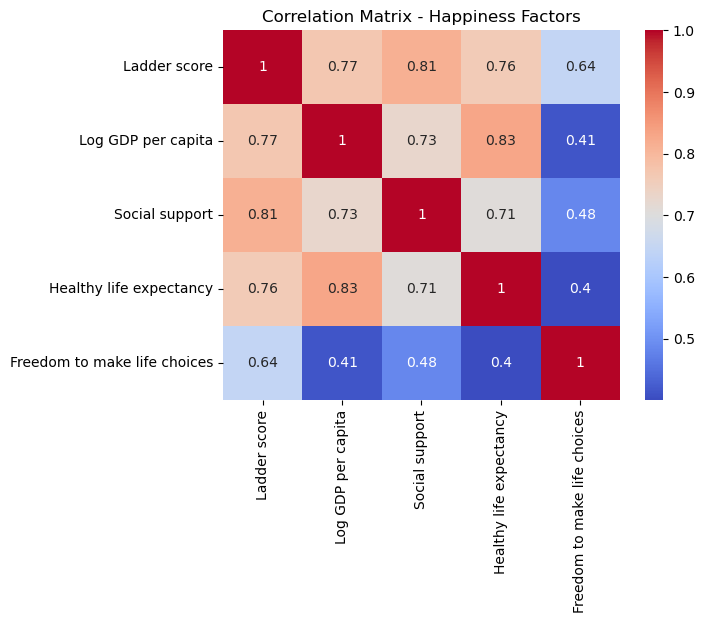

In [15]:
sb.heatmap(
    df[["Ladder score", "Log GDP per capita", "Social support", "Healthy life expectancy", "Freedom to make life choices"
    ]].corr(), annot=True,
    cmap="coolwarm")

plt.title("Correlation Matrix - Happiness Factors")
plt.show()

## Country Ranking (Top & Bottom)
### Top 10 happiest countries

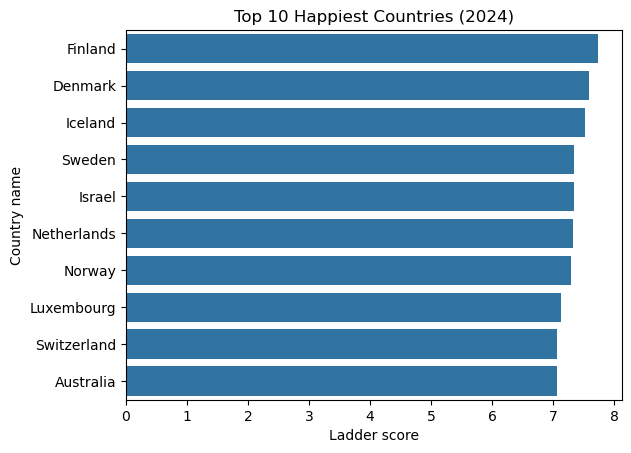

In [20]:
top10 = df.sort_values("Ladder score", ascending=False).head(10)

sb.barplot( data=top10, y="Country name", x="Ladder score")
plt.title("Top 10 Happiest Countries (2024)")
plt.show()

## Top 10 Unhappy countries

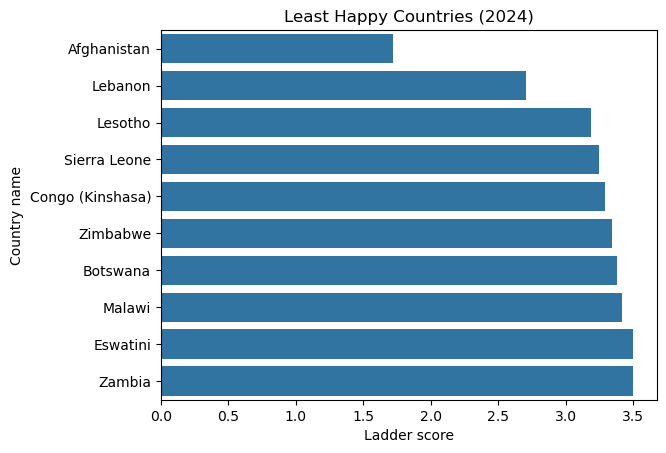

In [19]:
bottom10 = df.sort_values("Ladder score").head(10)

sb.barplot(data=bottom10, y="Country name", x="Ladder score")
plt.title("Least Happy Countries (2024)")
plt.show()

## Predicting Happiness Using Linear Model

In [35]:
features = ["Log GDP per capita", "Social support", "Healthy life expectancy","Freedom to make life choices"]

data = df[features + ["Ladder score"]].dropna()

X = data[features]
y = data["Ladder score"]

In [36]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
y_pred = model.predict(x_test)

In [39]:
from sklearn.metrics import  r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7772409754257689


In [40]:
coefficients = pd.DataFrame({"Feature": features, "Impact": model.coef_})

print(coefficients.sort_values(by="Impact", ascending=False))

                        Feature    Impact
3  Freedom to make life choices  2.342921
1                Social support  1.327661
2       Healthy life expectancy  1.094364
0            Log GDP per capita  0.602544


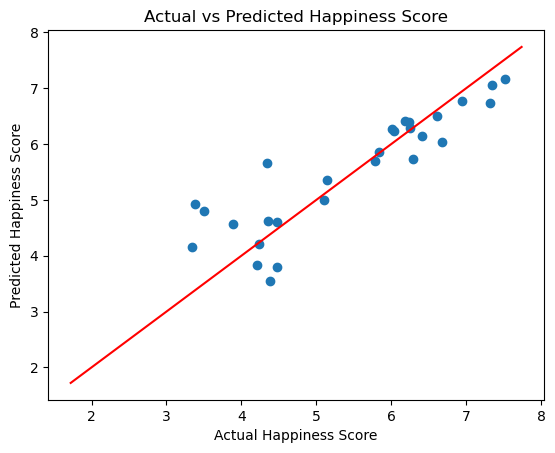

In [41]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.title("Actual vs Predicted Happiness Score")

plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")

plt.show()

## GDP per capita is the strongest predictor of happiness, but social support and life expectancy also significantly influence well-being, confirming that happiness is multi-dimensional.